In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier
import sys; sys.path.insert(0, '../..')
from feature_engineering import add_trend_features


## 1-day Horizon


In [2]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [3]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 1

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. y = 1 if the spread increases over the next H days, else 0.
y_now    = df['BAA10Y']
y_future = df['BAA10Y'].shift(-H)
delta    = y_future - y_now

y_label = (delta > 0).astype(int)

X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where the target is undefined, the move is flat (delta == 0),
# or any feature is NaN. The trend features (rolling windows) introduce
# NaN at the series start; flat moves are excluded so the task is strictly
# directional (up vs down).
mask = delta.notna() & (delta != 0) & X_full.notna().all(axis=1)
X   = X_full.loc[mask]
y   = y_label.loc[mask]
y_t = y_now.loc[mask]  # current spread (kept for plotting context)

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {y.mean():.2%}, down = {1 - y.mean():.2%}")


Horizon H = 1 day(s)
Samples: 7352  (1990-03-05 → 2025-12-30)
Class balance: up = 48.63%, down = 51.37%


In [4]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows) "
          f"| up-rate train={f['y_train'].mean():.2%} test={f['y_test'].mean():.2%}")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-28 (2225 rows) | test 2000-10-01 → 2000-12-28 (53 rows) | up-rate train=50.43% test=60.38%
  2001: train 1990-03-05 → 2001-09-30 (2433 rows) | test 2001-10-01 → 2001-12-30 (53 rows) | up-rate train=50.80% test=39.62%
  2002: train 1990-03-05 → 2002-09-30 (2654 rows) | test 2002-10-01 → 2002-12-29 (51 rows) | up-rate train=50.75% test=47.06%
  2025: train 1995-10-01 → 2025-09-30 (6101 rows) | test 2025-10-01 → 2025-12-30 (52 rows) | up-rate train=48.34% test=48.08%


In [5]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (1 - OOB accuracy)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.4804  depth mean= 25.9  min= 19  max= 40
n_estimators= 200  OOB error=0.4706  depth mean= 26.2  min= 19  max= 40
n_estimators= 300  OOB error=0.4607  depth mean= 25.9  min= 19  max= 40
n_estimators= 400  OOB error=0.4701  depth mean= 25.9  min= 19  max= 40
n_estimators= 500  OOB error=0.4706  depth mean= 25.9  min= 19  max= 40
n_estimators= 600  OOB error=0.4701  depth mean= 25.9  min= 19  max= 40
n_estimators= 700  OOB error=0.4683  depth mean= 25.9  min= 19  max= 40
n_estimators= 800  OOB error=0.4683  depth mean= 25.9  min= 19  max= 40
n_estimators= 900  OOB error=0.4674  depth mean= 26.0  min= 19  max= 40
n_estimators=1000  OOB error=0.4670  depth mean= 26.0  min= 19  max= 40
n_estimators=1100  OOB error=0.4661  depth mean= 26.0  min= 19  max= 43
n_estimators=1200  OOB error=0.4643  depth mean= 26.1  min= 19  max= 43
n_estimators=1300  OOB error=0.4674  depth mean= 26.1  min= 19  max= 43
n_estimators=1400  OOB error=0.4661  depth mean= 26.1  min= 19  

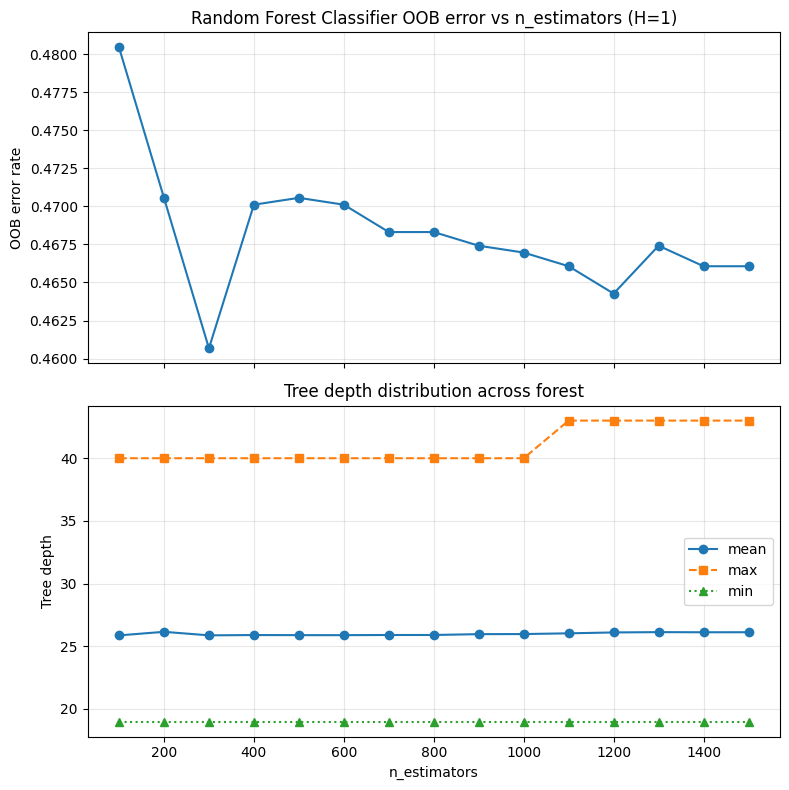

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest Classifier OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results    = []
all_y_test      = []
all_y_pred      = []
all_y_proba     = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    proba       = rf_fold.predict_proba(fold['X_test'])[:, 1]
    y_pred_arr  = (proba >= 0.5).astype(int)
    y_pred_fold = pd.Series(y_pred_arr, index=fold['y_test'].index)
    proba_fold  = pd.Series(proba,      index=fold['y_test'].index)
    y_true      = fold['y_test']

    acc       = accuracy_score(y_true, y_pred_fold)
    # Always-majority baseline: predict whichever class is more common in test.
    naive_acc = max(y_true.mean(), 1 - y_true.mean())
    auc       = roc_auc_score(y_true, proba) if y_true.nunique() > 1 else np.nan
    ll        = log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6), labels=[0, 1])

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'acc': acc, 'acc_naive': naive_acc,
        'auc': auc, 'log_loss': ll,
        'up_rate': y_true.mean(),
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_proba.append(proba_fold)
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else "  n/a"
    print(f"{fold['year']}: Acc={acc:.2%} (naive={naive_acc:.2%})  "
          f"AUC={auc_str}  LogLoss={ll:.4f}  UpRate={y_true.mean():.2%}")

y_test_all  = pd.concat(all_y_test)
y_pred_all  = pd.concat(all_y_pred)
y_proba_all = pd.concat(all_y_proba)
results_df  = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'Acc':>8} {'Naive':>8} {'AUC':>7} {'LogLoss':>9}")
print("-" * 46)
print(f"{'Mean':8} {results_df['acc'].mean():>8.2%} {results_df['acc_naive'].mean():>8.2%} "
      f"{results_df['auc'].mean():>7.3f} {results_df['log_loss'].mean():>9.4f}")


Best n_estimators: 300

2000: Acc=49.06% (naive=60.38%)  AUC=0.536  LogLoss=0.7444  UpRate=60.38%
2001: Acc=62.26% (naive=60.38%)  AUC=0.474  LogLoss=0.6914  UpRate=39.62%
2002: Acc=56.86% (naive=52.94%)  AUC=0.591  LogLoss=0.6830  UpRate=47.06%
2003: Acc=44.90% (naive=61.22%)  AUC=0.458  LogLoss=0.7143  UpRate=38.78%
2004: Acc=62.79% (naive=58.14%)  AUC=0.651  LogLoss=0.6654  UpRate=41.86%
2005: Acc=67.57% (naive=51.35%)  AUC=0.684  LogLoss=0.6623  UpRate=48.65%
2006: Acc=54.55% (naive=56.82%)  AUC=0.577  LogLoss=0.6747  UpRate=43.18%
2007: Acc=44.44% (naive=61.11%)  AUC=0.475  LogLoss=0.7345  UpRate=61.11%
2008: Acc=39.66% (naive=60.34%)  AUC=0.510  LogLoss=0.7385  UpRate=60.34%
2009: Acc=48.15% (naive=57.41%)  AUC=0.509  LogLoss=0.7048  UpRate=42.59%
2010: Acc=45.45% (naive=63.64%)  AUC=0.487  LogLoss=0.6889  UpRate=36.36%
2011: Acc=61.82% (naive=52.73%)  AUC=0.709  LogLoss=0.6585  UpRate=52.73%
2012: Acc=41.67% (naive=60.42%)  AUC=0.476  LogLoss=0.7460  UpRate=39.58%
2013: Acc=31.8

In [8]:
overall_acc    = accuracy_score(y_test_all, y_pred_all)
naive_baseline = max(y_test_all.mean(), 1 - y_test_all.mean())
auc_overall    = roc_auc_score(y_test_all, y_proba_all)

up_mask   = y_test_all == 1
down_mask = y_test_all == 0

print(f"Overall classification accuracy across all folds (n={len(y_test_all)}):")
print(f"  RF classifier           : {overall_acc:.2%}")
print(f"  Always-majority baseline: {naive_baseline:.2%}")
print(f"  AUC (pooled)            : {auc_overall:.3f}")
print()
print("Confusion matrix (rows = actual, cols = predicted):")
cm = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
print(pd.DataFrame(cm, index=['actual_DOWN', 'actual_UP'],
                       columns=['pred_DOWN', 'pred_UP']))
print()
print("Per-class breakdown:")
print(classification_report(y_test_all, y_pred_all,
                            target_names=['DOWN', 'UP'], digits=3))
print(f"Recall on UP   ({up_mask.sum():4d} days): {(y_pred_all[up_mask]   == 1).mean():.2%}")
print(f"Recall on DOWN ({down_mask.sum():4d} days): {(y_pred_all[down_mask] == 0).mean():.2%}")


Overall classification accuracy across all folds (n=1296):
  RF classifier           : 50.31%
  Always-majority baseline: 54.78%
  AUC (pooled)            : 0.489

Confusion matrix (rows = actual, cols = predicted):
             pred_DOWN  pred_UP
actual_DOWN        365      345
actual_UP          299      287

Per-class breakdown:
              precision    recall  f1-score   support

        DOWN      0.550     0.514     0.531       710
          UP      0.454     0.490     0.471       586

    accuracy                          0.503      1296
   macro avg      0.502     0.502     0.501      1296
weighted avg      0.506     0.503     0.504      1296

Recall on UP   ( 586 days): 48.98%
Recall on DOWN ( 710 days): 51.41%


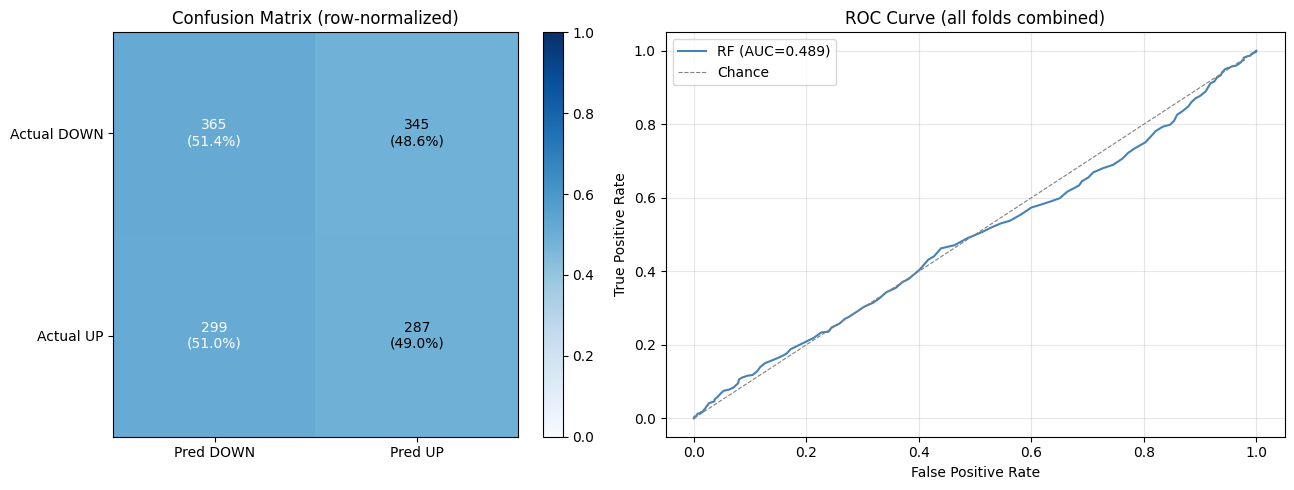

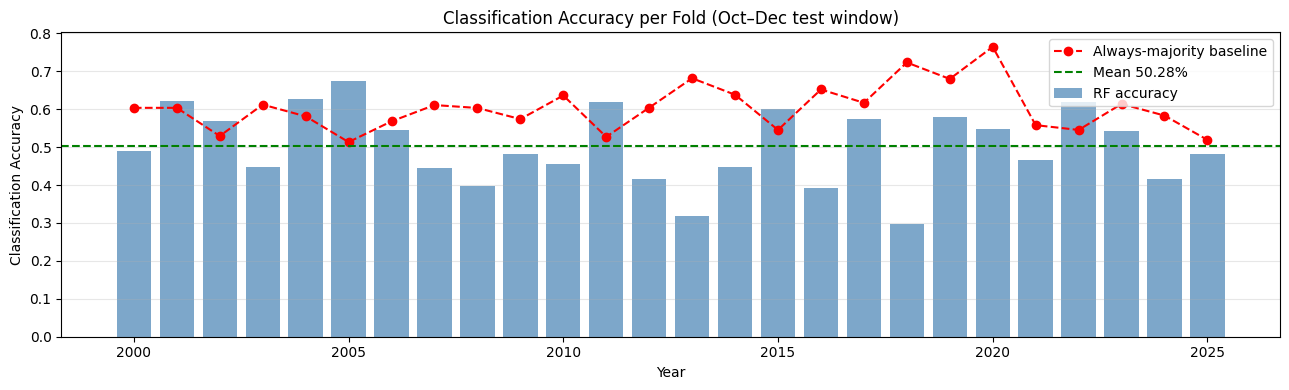

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm      = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred DOWN', 'Pred UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual DOWN', 'Actual UP'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.1%})",
                ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black')
ax.set_title('Confusion Matrix (row-normalized)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_all, y_proba_all)
ax.plot(fpr, tpr, color='steelblue', lw=1.5,
        label=f'RF (AUC={roc_auc_score(y_test_all, y_proba_all):.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=0.8, linestyle='--', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (all folds combined)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['acc'], color='steelblue', alpha=0.7,
       label='RF accuracy')
ax.plot(results_df.index, results_df['acc_naive'], color='red', lw=1.5,
        marker='o', linestyle='--', label='Always-majority baseline')
ax.axhline(results_df['acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Classification Accuracy')
ax.set_title('Classification Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


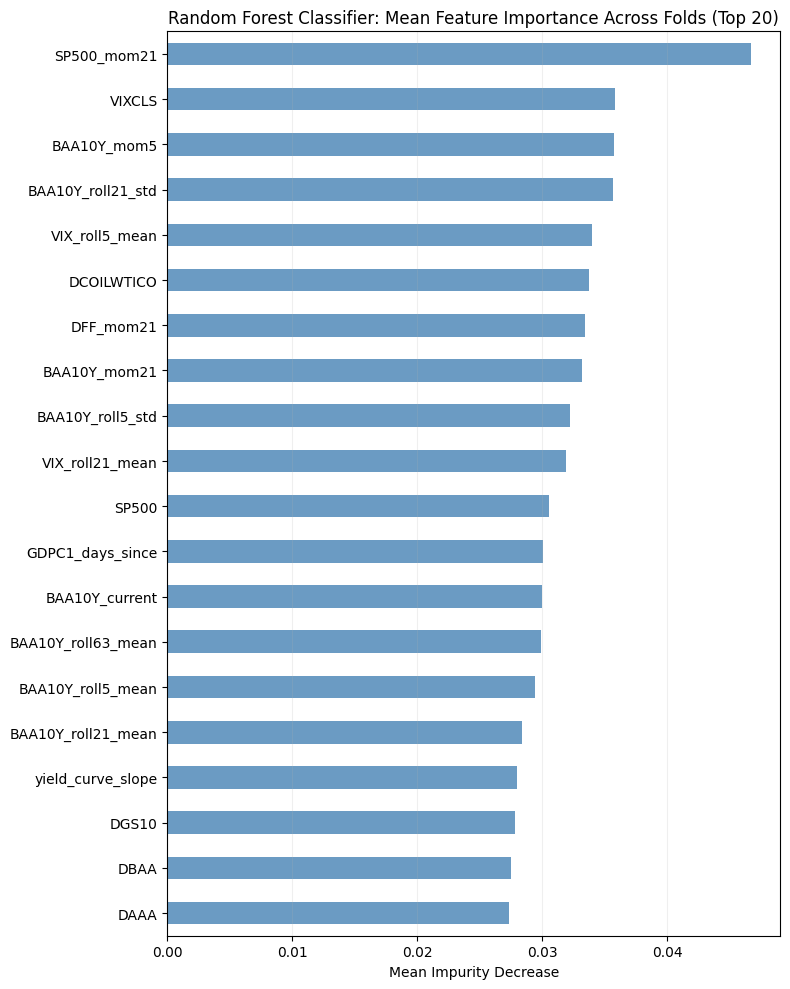

In [10]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest Classifier: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()


## 7-day Horizon


In [11]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [12]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 7

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. y = 1 if the spread increases over the next H days, else 0.
y_now    = df['BAA10Y']
y_future = df['BAA10Y'].shift(-H)
delta    = y_future - y_now

y_label = (delta > 0).astype(int)

X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where the target is undefined, the move is flat (delta == 0),
# or any feature is NaN. The trend features (rolling windows) introduce
# NaN at the series start; flat moves are excluded so the task is strictly
# directional (up vs down).
mask = delta.notna() & (delta != 0) & X_full.notna().all(axis=1)
X   = X_full.loc[mask]
y   = y_label.loc[mask]
y_t = y_now.loc[mask]  # current spread (kept for plotting context)

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {y.mean():.2%}, down = {1 - y.mean():.2%}")


Horizon H = 7 day(s)
Samples: 12036  (1990-03-05 → 2025-12-25)
Class balance: up = 47.72%, down = 52.28%


In [13]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows) "
          f"| up-rate train={f['y_train'].mean():.2%} test={f['y_test'].mean():.2%}")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-30 (3540 rows) | test 2000-10-01 → 2000-12-31 (91 rows) | up-rate train=49.35% test=68.13%
  2001: train 1990-03-05 → 2001-09-30 (3890 rows) | test 2001-10-01 → 2001-12-31 (87 rows) | up-rate train=49.90% test=22.99%
  2002: train 1990-03-05 → 2002-09-30 (4231 rows) | test 2002-10-01 → 2002-12-31 (85 rows) | up-rate train=50.60% test=38.82%
  2025: train 1995-10-01 → 2025-09-29 (10077 rows) | test 2025-10-01 → 2025-12-25 (80 rows) | up-rate train=47.41% test=51.25%


In [14]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (1 - OOB accuracy)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.1017  depth mean= 23.1  min= 18  max= 31
n_estimators= 200  OOB error=0.0989  depth mean= 23.1  min= 18  max= 32
n_estimators= 300  OOB error=0.0977  depth mean= 23.2  min= 18  max= 33
n_estimators= 400  OOB error=0.0992  depth mean= 23.1  min= 18  max= 33
n_estimators= 500  OOB error=0.0949  depth mean= 23.2  min= 18  max= 34
n_estimators= 600  OOB error=0.0955  depth mean= 23.2  min= 18  max= 34
n_estimators= 700  OOB error=0.0955  depth mean= 23.3  min= 17  max= 34
n_estimators= 800  OOB error=0.0938  depth mean= 23.3  min= 17  max= 34
n_estimators= 900  OOB error=0.0938  depth mean= 23.3  min= 17  max= 34
n_estimators=1000  OOB error=0.0941  depth mean= 23.2  min= 17  max= 34
n_estimators=1100  OOB error=0.0935  depth mean= 23.2  min= 17  max= 34
n_estimators=1200  OOB error=0.0938  depth mean= 23.2  min= 17  max= 34
n_estimators=1300  OOB error=0.0935  depth mean= 23.2  min= 17  max= 37
n_estimators=1400  OOB error=0.0935  depth mean= 23.2  min= 17  

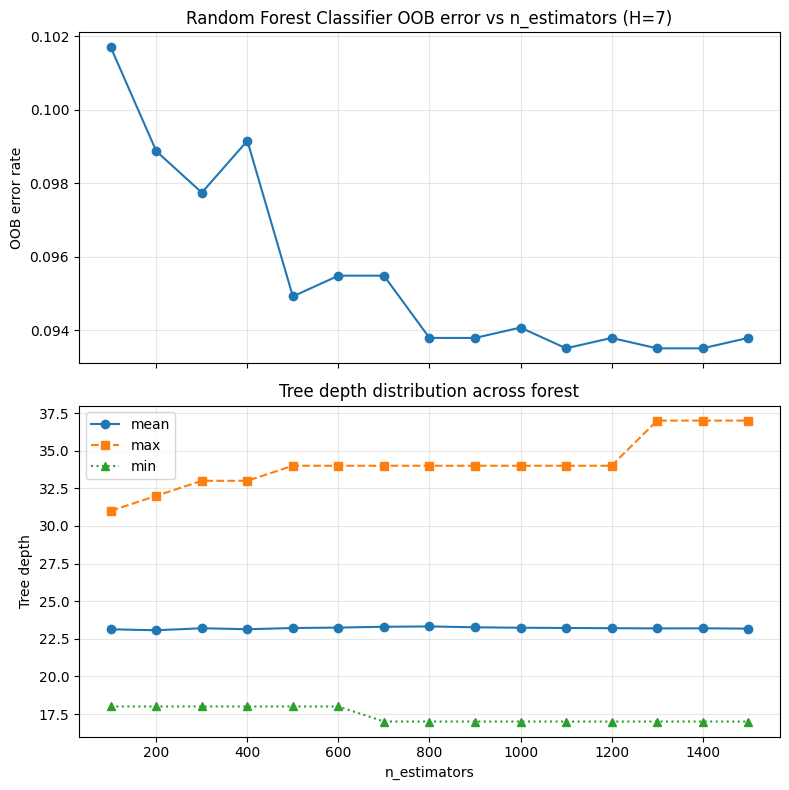

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest Classifier OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results    = []
all_y_test      = []
all_y_pred      = []
all_y_proba     = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    proba       = rf_fold.predict_proba(fold['X_test'])[:, 1]
    y_pred_arr  = (proba >= 0.5).astype(int)
    y_pred_fold = pd.Series(y_pred_arr, index=fold['y_test'].index)
    proba_fold  = pd.Series(proba,      index=fold['y_test'].index)
    y_true      = fold['y_test']

    acc       = accuracy_score(y_true, y_pred_fold)
    # Always-majority baseline: predict whichever class is more common in test.
    naive_acc = max(y_true.mean(), 1 - y_true.mean())
    auc       = roc_auc_score(y_true, proba) if y_true.nunique() > 1 else np.nan
    ll        = log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6), labels=[0, 1])

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'acc': acc, 'acc_naive': naive_acc,
        'auc': auc, 'log_loss': ll,
        'up_rate': y_true.mean(),
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_proba.append(proba_fold)
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else "  n/a"
    print(f"{fold['year']}: Acc={acc:.2%} (naive={naive_acc:.2%})  "
          f"AUC={auc_str}  LogLoss={ll:.4f}  UpRate={y_true.mean():.2%}")

y_test_all  = pd.concat(all_y_test)
y_pred_all  = pd.concat(all_y_pred)
y_proba_all = pd.concat(all_y_proba)
results_df  = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'Acc':>8} {'Naive':>8} {'AUC':>7} {'LogLoss':>9}")
print("-" * 46)
print(f"{'Mean':8} {results_df['acc'].mean():>8.2%} {results_df['acc_naive'].mean():>8.2%} "
      f"{results_df['auc'].mean():>7.3f} {results_df['log_loss'].mean():>9.4f}")


Best n_estimators: 1100

2000: Acc=31.87% (naive=68.13%)  AUC=0.572  LogLoss=0.9163  UpRate=68.13%
2001: Acc=66.67% (naive=77.01%)  AUC=0.041  LogLoss=0.7333  UpRate=22.99%
2002: Acc=41.18% (naive=61.18%)  AUC=0.625  LogLoss=0.7820  UpRate=38.82%
2003: Acc=50.62% (naive=64.20%)  AUC=0.624  LogLoss=0.7609  UpRate=35.80%
2004: Acc=65.79% (naive=81.58%)  AUC=0.389  LogLoss=0.6203  UpRate=18.42%
2005: Acc=47.62% (naive=53.57%)  AUC=0.544  LogLoss=0.6863  UpRate=46.43%
2006: Acc=60.71% (naive=64.29%)  AUC=0.723  LogLoss=0.6771  UpRate=35.71%
2007: Acc=29.67% (naive=74.73%)  AUC=0.468  LogLoss=0.8690  UpRate=74.73%
2008: Acc=42.39% (naive=53.26%)  AUC=0.393  LogLoss=0.7092  UpRate=53.26%
2009: Acc=55.00% (naive=62.50%)  AUC=0.504  LogLoss=0.7397  UpRate=37.50%
2010: Acc=26.37% (naive=73.63%)  AUC=0.424  LogLoss=0.8135  UpRate=26.37%
2011: Acc=64.71% (naive=52.94%)  AUC=0.629  LogLoss=0.6742  UpRate=52.94%
2012: Acc=56.67% (naive=56.67%)  AUC=0.654  LogLoss=0.6746  UpRate=43.33%
2013: Acc=18.

In [17]:
overall_acc    = accuracy_score(y_test_all, y_pred_all)
naive_baseline = max(y_test_all.mean(), 1 - y_test_all.mean())
auc_overall    = roc_auc_score(y_test_all, y_proba_all)

up_mask   = y_test_all == 1
down_mask = y_test_all == 0

print(f"Overall classification accuracy across all folds (n={len(y_test_all)}):")
print(f"  RF classifier           : {overall_acc:.2%}")
print(f"  Always-majority baseline: {naive_baseline:.2%}")
print(f"  AUC (pooled)            : {auc_overall:.3f}")
print()
print("Confusion matrix (rows = actual, cols = predicted):")
cm = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
print(pd.DataFrame(cm, index=['actual_DOWN', 'actual_UP'],
                       columns=['pred_DOWN', 'pred_UP']))
print()
print("Per-class breakdown:")
print(classification_report(y_test_all, y_pred_all,
                            target_names=['DOWN', 'UP'], digits=3))
print(f"Recall on UP   ({up_mask.sum():4d} days): {(y_pred_all[up_mask]   == 1).mean():.2%}")
print(f"Recall on DOWN ({down_mask.sum():4d} days): {(y_pred_all[down_mask] == 0).mean():.2%}")


Overall classification accuracy across all folds (n=2220):
  RF classifier           : 48.02%
  Always-majority baseline: 58.47%
  AUC (pooled)            : 0.472

Confusion matrix (rows = actual, cols = predicted):
             pred_DOWN  pred_UP
actual_DOWN        586      712
actual_UP          442      480

Per-class breakdown:
              precision    recall  f1-score   support

        DOWN      0.570     0.451     0.504      1298
          UP      0.403     0.521     0.454       922

    accuracy                          0.480      2220
   macro avg      0.486     0.486     0.479      2220
weighted avg      0.501     0.480     0.483      2220

Recall on UP   ( 922 days): 52.06%
Recall on DOWN (1298 days): 45.15%


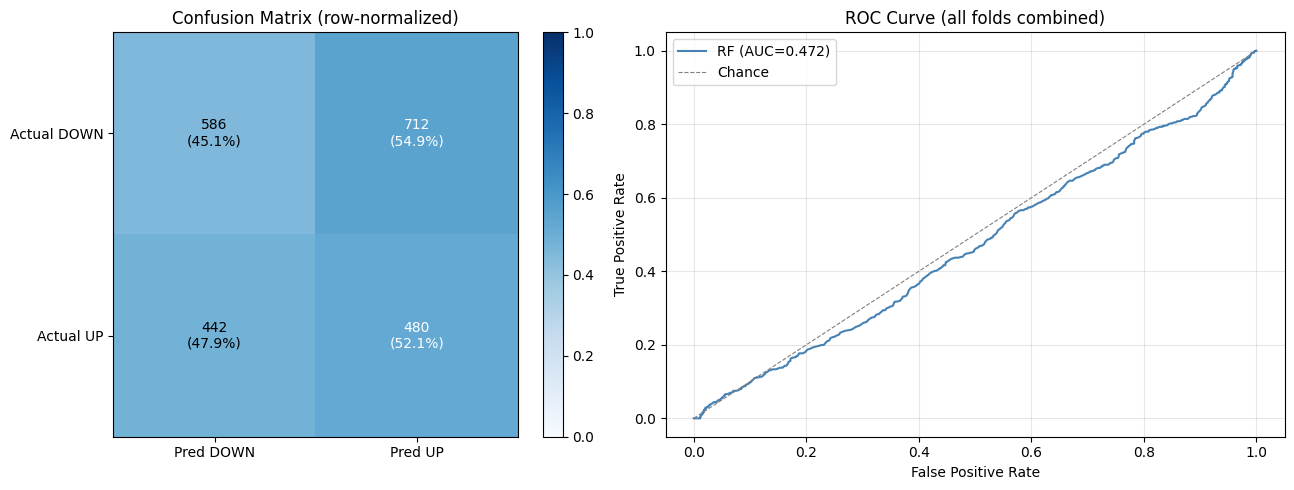

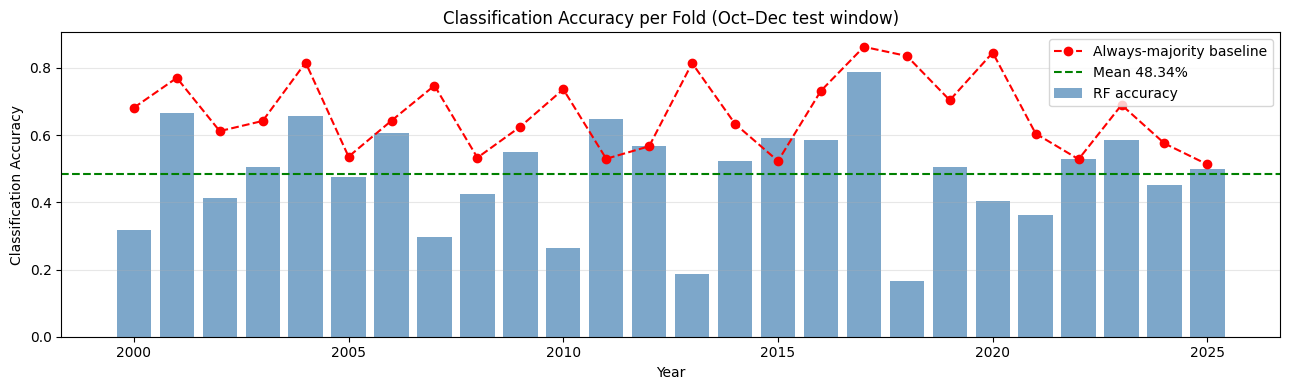

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm      = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred DOWN', 'Pred UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual DOWN', 'Actual UP'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.1%})",
                ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black')
ax.set_title('Confusion Matrix (row-normalized)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_all, y_proba_all)
ax.plot(fpr, tpr, color='steelblue', lw=1.5,
        label=f'RF (AUC={roc_auc_score(y_test_all, y_proba_all):.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=0.8, linestyle='--', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (all folds combined)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['acc'], color='steelblue', alpha=0.7,
       label='RF accuracy')
ax.plot(results_df.index, results_df['acc_naive'], color='red', lw=1.5,
        marker='o', linestyle='--', label='Always-majority baseline')
ax.axhline(results_df['acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Classification Accuracy')
ax.set_title('Classification Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


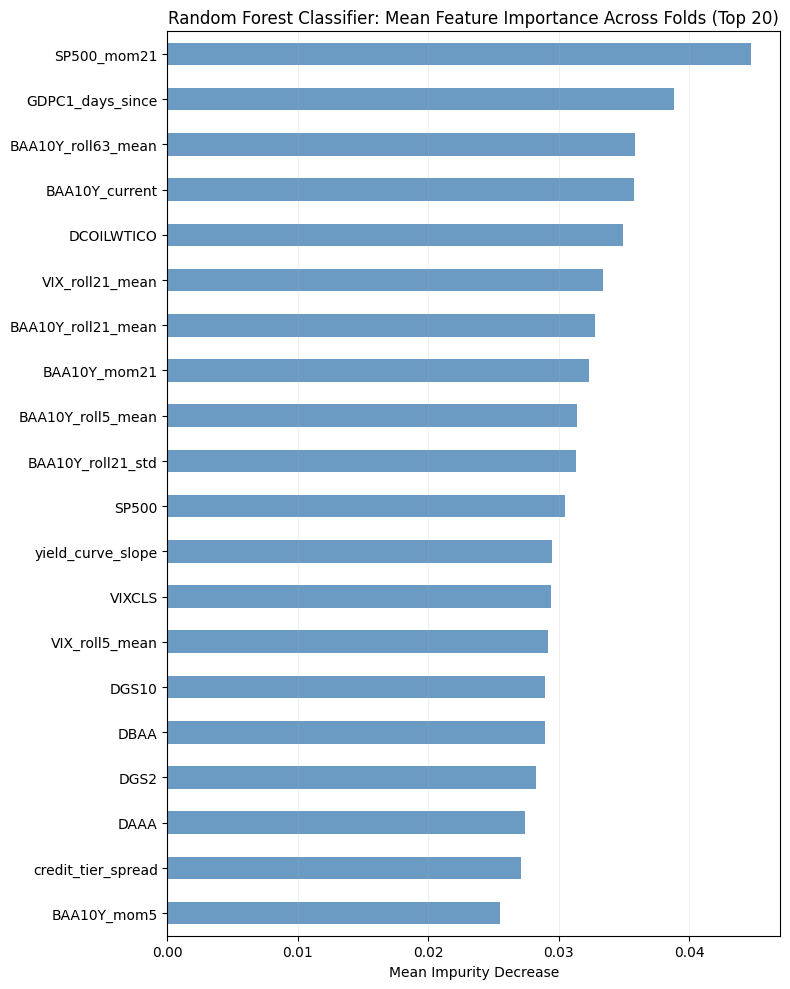

In [19]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest Classifier: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()


## 28-day Horizon


In [20]:
df = pd.read_csv('../../data/dataset.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)


,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [21]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 28

# Supervised setup: features at time t predict the *direction* of BAA10Y at t+H
# relative to t. y = 1 if the spread increases over the next H days, else 0.
y_now    = df['BAA10Y']
y_future = df['BAA10Y'].shift(-H)
delta    = y_future - y_now

y_label = (delta > 0).astype(int)

X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where the target is undefined, the move is flat (delta == 0),
# or any feature is NaN. The trend features (rolling windows) introduce
# NaN at the series start; flat moves are excluded so the task is strictly
# directional (up vs down).
mask = delta.notna() & (delta != 0) & X_full.notna().all(axis=1)
X   = X_full.loc[mask]
y   = y_label.loc[mask]
y_t = y_now.loc[mask]  # current spread (kept for plotting context)

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")
print(f"Class balance: up = {y.mean():.2%}, down = {1 - y.mean():.2%}")


Horizon H = 28 day(s)
Samples: 12568  (1990-03-05 → 2025-12-04)
Class balance: up = 47.75%, down = 52.25%


In [22]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows) "
          f"| up-rate train={f['y_train'].mean():.2%} test={f['y_test'].mean():.2%}")


Folds: 26  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-30 (3722 rows) | test 2000-10-01 → 2000-12-31 (92 rows) | up-rate train=51.29% test=61.96%
  2001: train 1990-03-05 → 2001-09-30 (4083 rows) | test 2001-10-01 → 2001-12-31 (91 rows) | up-rate train=52.39% test=2.20%
  2002: train 1990-03-05 → 2002-09-30 (4445 rows) | test 2002-10-01 → 2002-12-31 (92 rows) | up-rate train=53.32% test=13.04%
  2025: train 1995-10-01 → 2025-09-30 (10532 rows) | test 2025-10-01 → 2025-12-04 (62 rows) | up-rate train=47.21% test=58.06%


In [23]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestClassifier(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_error  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    err = 1.0 - rf.oob_score_  # OOB error rate (1 - OOB accuracy)
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_error.append(err)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB error={err:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")


n_estimators= 100  OOB error=0.0476  depth mean= 19.7  min= 15  max= 26
n_estimators= 200  OOB error=0.0446  depth mean= 19.9  min= 15  max= 30
n_estimators= 300  OOB error=0.0457  depth mean= 19.9  min= 15  max= 30
n_estimators= 400  OOB error=0.0462  depth mean= 19.9  min= 15  max= 30
n_estimators= 500  OOB error=0.0467  depth mean= 19.9  min= 15  max= 30
n_estimators= 600  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators= 700  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators= 800  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators= 900  OOB error=0.0459  depth mean= 20.0  min= 15  max= 30
n_estimators=1000  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators=1100  OOB error=0.0462  depth mean= 20.0  min= 15  max= 30
n_estimators=1200  OOB error=0.0470  depth mean= 20.0  min= 15  max= 30
n_estimators=1300  OOB error=0.0465  depth mean= 20.0  min= 15  max= 30
n_estimators=1400  OOB error=0.0467  depth mean= 20.0  min= 15  

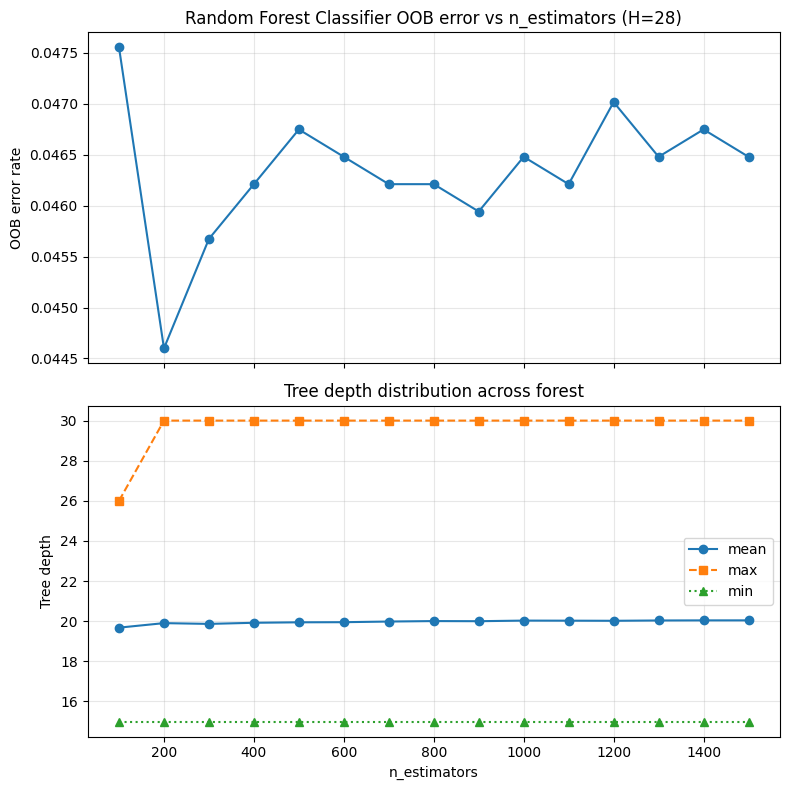

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_error, marker='o')
axes[0].set_ylabel('OOB error rate')
axes[0].set_title(f'Random Forest Classifier OOB error vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
best_n = n_grid[np.argmin(oob_error)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results    = []
all_y_test      = []
all_y_pred      = []
all_y_proba     = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    proba       = rf_fold.predict_proba(fold['X_test'])[:, 1]
    y_pred_arr  = (proba >= 0.5).astype(int)
    y_pred_fold = pd.Series(y_pred_arr, index=fold['y_test'].index)
    proba_fold  = pd.Series(proba,      index=fold['y_test'].index)
    y_true      = fold['y_test']

    acc       = accuracy_score(y_true, y_pred_fold)
    # Always-majority baseline: predict whichever class is more common in test.
    naive_acc = max(y_true.mean(), 1 - y_true.mean())
    auc       = roc_auc_score(y_true, proba) if y_true.nunique() > 1 else np.nan
    ll        = log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6), labels=[0, 1])

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'acc': acc, 'acc_naive': naive_acc,
        'auc': auc, 'log_loss': ll,
        'up_rate': y_true.mean(),
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_proba.append(proba_fold)
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else "  n/a"
    print(f"{fold['year']}: Acc={acc:.2%} (naive={naive_acc:.2%})  "
          f"AUC={auc_str}  LogLoss={ll:.4f}  UpRate={y_true.mean():.2%}")

y_test_all  = pd.concat(all_y_test)
y_pred_all  = pd.concat(all_y_pred)
y_proba_all = pd.concat(all_y_proba)
results_df  = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'Acc':>8} {'Naive':>8} {'AUC':>7} {'LogLoss':>9}")
print("-" * 46)
print(f"{'Mean':8} {results_df['acc'].mean():>8.2%} {results_df['acc_naive'].mean():>8.2%} "
      f"{results_df['auc'].mean():>7.3f} {results_df['log_loss'].mean():>9.4f}")


Best n_estimators: 200

2000: Acc=70.65% (naive=61.96%)  AUC=0.530  LogLoss=0.6702  UpRate=61.96%
2001: Acc=91.21% (naive=97.80%)  AUC=0.618  LogLoss=0.5108  UpRate=2.20%
2002: Acc=13.04% (naive=86.96%)  AUC=0.272  LogLoss=1.7576  UpRate=13.04%
2003: Acc=25.88% (naive=87.06%)  AUC=0.909  LogLoss=0.7889  UpRate=12.94%
2004: Acc=98.88% (naive=100.00%)  AUC=  n/a  LogLoss=0.4446  UpRate=0.00%
2005: Acc=40.00% (naive=60.00%)  AUC=0.907  LogLoss=0.7249  UpRate=40.00%
2006: Acc=52.75% (naive=69.23%)  AUC=0.883  LogLoss=0.6612  UpRate=30.77%
2007: Acc=8.99% (naive=91.01%)  AUC=0.618  LogLoss=1.3400  UpRate=91.01%
2008: Acc=94.57% (naive=59.78%)  AUC=0.972  LogLoss=0.5183  UpRate=59.78%
2009: Acc=33.33% (naive=72.41%)  AUC=0.424  LogLoss=1.0128  UpRate=27.59%
2010: Acc=21.35% (naive=78.65%)  AUC=0.538  LogLoss=1.0584  UpRate=21.35%
2011: Acc=67.78% (naive=54.44%)  AUC=0.860  LogLoss=0.6157  UpRate=54.44%
2012: Acc=74.71% (naive=63.22%)  AUC=0.762  LogLoss=0.5942  UpRate=36.78%
2013: Acc=45.56%

In [26]:
overall_acc    = accuracy_score(y_test_all, y_pred_all)
naive_baseline = max(y_test_all.mean(), 1 - y_test_all.mean())
auc_overall    = roc_auc_score(y_test_all, y_proba_all)

up_mask   = y_test_all == 1
down_mask = y_test_all == 0

print(f"Overall classification accuracy across all folds (n={len(y_test_all)}):")
print(f"  RF classifier           : {overall_acc:.2%}")
print(f"  Always-majority baseline: {naive_baseline:.2%}")
print(f"  AUC (pooled)            : {auc_overall:.3f}")
print()
print("Confusion matrix (rows = actual, cols = predicted):")
cm = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
print(pd.DataFrame(cm, index=['actual_DOWN', 'actual_UP'],
                       columns=['pred_DOWN', 'pred_UP']))
print()
print("Per-class breakdown:")
print(classification_report(y_test_all, y_pred_all,
                            target_names=['DOWN', 'UP'], digits=3))
print(f"Recall on UP   ({up_mask.sum():4d} days): {(y_pred_all[up_mask]   == 1).mean():.2%}")
print(f"Recall on DOWN ({down_mask.sum():4d} days): {(y_pred_all[down_mask] == 0).mean():.2%}")


Overall classification accuracy across all folds (n=2288):
  RF classifier           : 50.17%
  Always-majority baseline: 63.77%
  AUC (pooled)            : 0.486

Confusion matrix (rows = actual, cols = predicted):
             pred_DOWN  pred_UP
actual_DOWN        647      812
actual_UP          328      501

Per-class breakdown:
              precision    recall  f1-score   support

        DOWN      0.664     0.443     0.532      1459
          UP      0.382     0.604     0.468       829

    accuracy                          0.502      2288
   macro avg      0.523     0.524     0.500      2288
weighted avg      0.561     0.502     0.509      2288

Recall on UP   ( 829 days): 60.43%
Recall on DOWN (1459 days): 44.35%


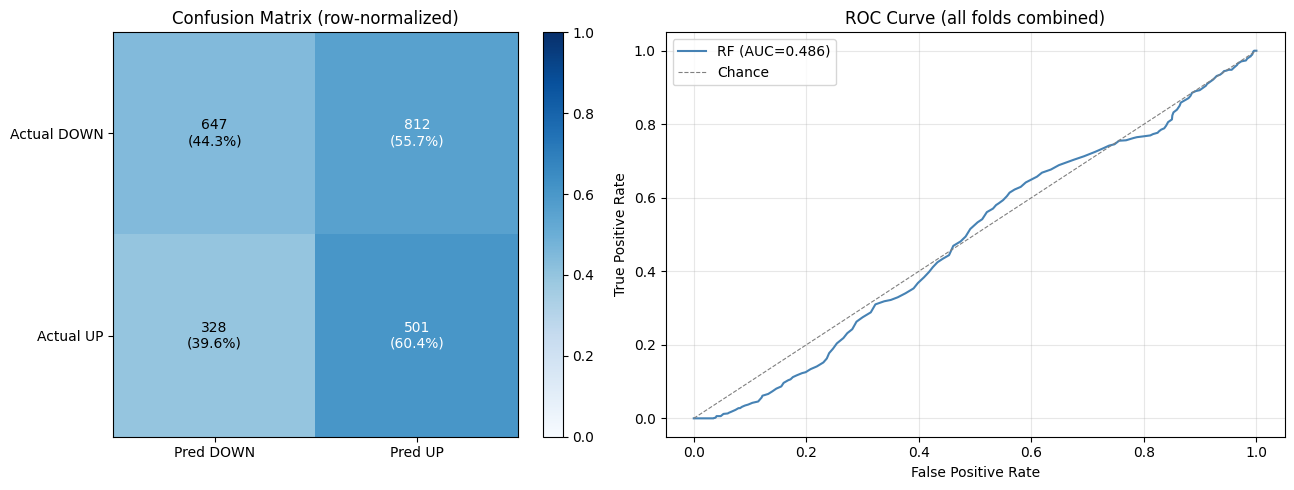

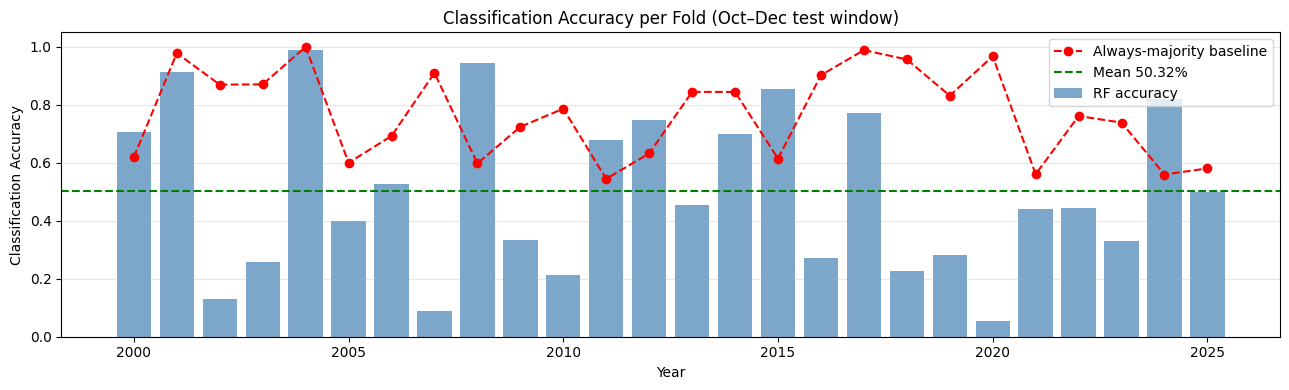

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm      = confusion_matrix(y_test_all, y_pred_all, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred DOWN', 'Pred UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual DOWN', 'Actual UP'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.1%})",
                ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black')
ax.set_title('Confusion Matrix (row-normalized)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_all, y_proba_all)
ax.plot(fpr, tpr, color='steelblue', lw=1.5,
        label=f'RF (AUC={roc_auc_score(y_test_all, y_proba_all):.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=0.8, linestyle='--', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (all folds combined)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['acc'], color='steelblue', alpha=0.7,
       label='RF accuracy')
ax.plot(results_df.index, results_df['acc_naive'], color='red', lw=1.5,
        marker='o', linestyle='--', label='Always-majority baseline')
ax.axhline(results_df['acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Classification Accuracy')
ax.set_title('Classification Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


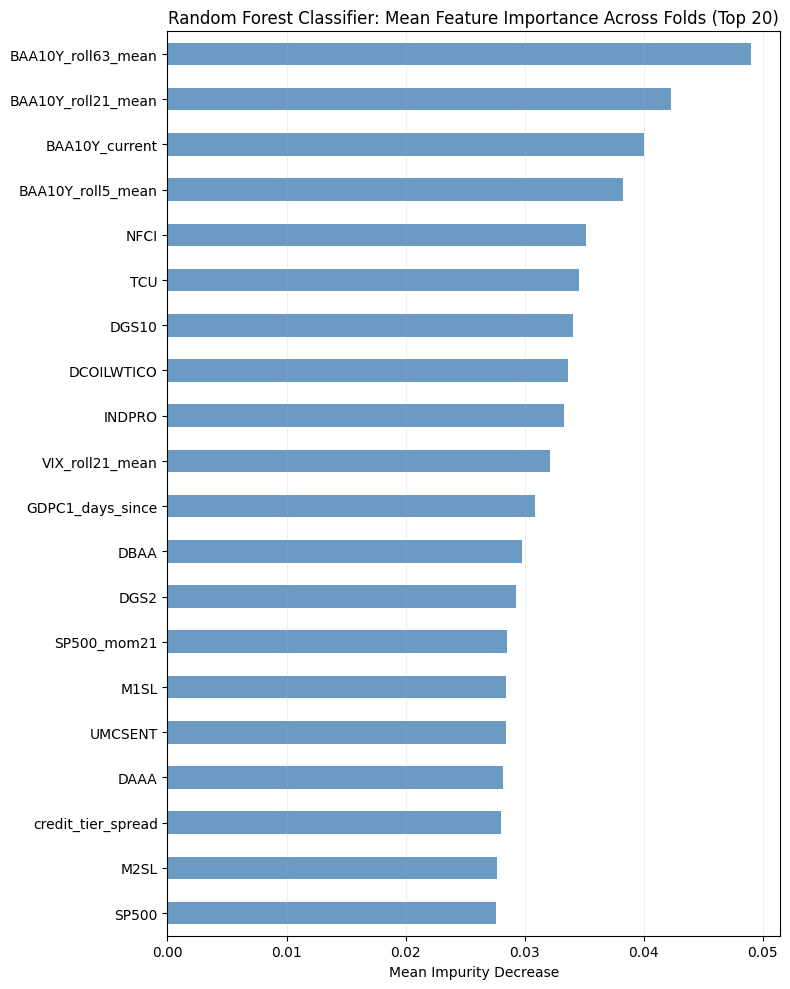

In [28]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest Classifier: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()
